# Lab 4-3: 지도학습의 4대 Challenging Problems 체감 실습

본 실습에서는 지도학습 모델을 실제 현장에 적용할 때 직면하게 되는 **4대 핵심 문제(Challenging Problems)**를 직접 구현하고 비교 실험하여 체감합니다.

---

### [학습 목표]
1. **기울기 소실 문제 (Vanishing Gradient)**: 깊은 신경망(20층)에서 Sigmoid 사용 시 역전파 기울기가 소실되어 학습이 중단되는 현상을 체감하고, ReLU로의 전환 효과를 확인합니다.
2. **과적합 문제 (Overfitting - 모델 복잡도)**: 동일한 데이터셋에서 단순한 모델과 복잡한(파라미터가 많은) 모델의 일반화 격차(Train vs Val Loss)를 비교합니다.
3. **레이블 데이터 부족 문제 (Overfitting - 데이터 크기)**: 복잡한 신경망에 작은 데이터셋(100개)과 충분한 데이터셋(2000개)을 적용했을 때의 과적합 차이를 체감합니다.
4. **클래스 불균형 문제 (Class Imbalance)**: 다수 클래스 90%, 소수 클래스 10% 불균형 데이터에서 전체 Accuracy 90%라는 '정확도의 함정'을 확인하고, 균형 잡힌 테스트셋 검증을 통해 모델의 실체를 체감합니다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 시드 고정
tf.random.set_seed(42)
np.random.seed(42)
print("TensorFlow 버전:", tf.__version__)


I0000 00:00:1790074452.358613     905 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790074452.535359     905 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790074456.070484     905 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 버전: 2.21.0


---
## Part 1. 기울기 소실 문제 (Vanishing Gradient Problem)

역전파(Backpropagation) 과정에서 연쇄 법칙(Chain Rule)에 의해 미분값이 누적 곱셈됩니다.
Sigmoid 활성화 함수의 도함수 최댓값은 $0.25$이므로, 층이 깊어질수록 출력층의 기울기가 입력층 방향으로 가면서 지수적으로 $0$에 수렴합니다.

- **실험 1-1**: 20층 Sigmoid 심층망 vs 3층 Sigmoid 천층망 학습 비교
- **실험 1-2**: 20층 Sigmoid 심층망 vs 20층 ReLU 심층망 학습 비교


### 1-1. 데이터셋 준비 (`make_moons`)
2개의 초승달 모양으로 분포된 비선형 이진 분류 데이터셋을 생성하고 표준화(StandardScaler)를 수행합니다.


In [2]:
# make_moons 데이터셋 (2000개 샘플)
X, y = make_moons(n_samples=2000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"X_train 형태: {X_train.shape}, y_train 분포: {np.bincount(y_train)}")


X_train 형태: (1600, 2), y_train 분포: [803 797]


### 1-2. 모델 생성 함수 정의 (깊은 망 vs 얕은 망)


In [3]:
def build_deep_model(activation="sigmoid", layers=20):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(2,)))
    for _ in range(layers):
        # ✅ 32개 뉴런 + 전달받은 activation
        model.add(tf.keras.layers.Dense(32, activation=activation))
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def build_shallow_model(activation="sigmoid", layers=3):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(2,)))
    for _ in range(layers):
        # ✅ 32개 뉴런 + 전달받은 activation
        model.add(tf.keras.layers.Dense(32, activation=activation))
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 1-3. 깊은 네트워크(20층) vs 얕은 네트워크(3층) Sigmoid 학습 및 비교


1. 깊은 망(20층 Sigmoid) 학습 중...


2. 얕은 망(3층 Sigmoid) 학습 중...


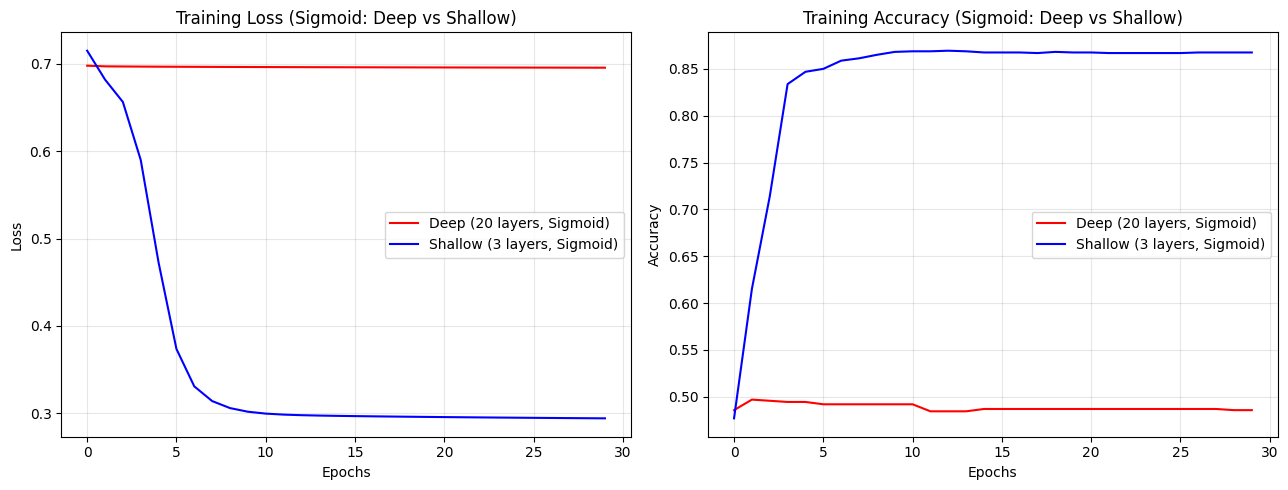

In [4]:
# 깊은 네트워크 (20층 Sigmoid)
print("1. 깊은 망(20층 Sigmoid) 학습 중...")
deep_model = build_deep_model(activation="sigmoid", layers=20)
history_deep = deep_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=32, verbose=0)

# 얕은 네트워크 (3층 Sigmoid)
print("2. 얕은 망(3층 Sigmoid) 학습 중...")
shallow_model = build_shallow_model(activation="sigmoid", layers=3)
history_shallow = shallow_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=32, verbose=0)

# 비교 시각화
plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.plot(history_deep.history['loss'], label="Deep (20 layers, Sigmoid)", color='red')
plt.plot(history_shallow.history['loss'], label="Shallow (3 layers, Sigmoid)", color='blue')
plt.title("Training Loss (Sigmoid: Deep vs Shallow)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_deep.history['accuracy'], label="Deep (20 layers, Sigmoid)", color='red')
plt.plot(history_shallow.history['accuracy'], label="Shallow (3 layers, Sigmoid)", color='blue')
plt.title("Training Accuracy (Sigmoid: Deep vs Shallow)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 1-4. ReLU 활성화 함수로 개선된 깊은 네트워크 학습 비교
Sigmoid 대신 양수 영역에서 기울기가 1로 유지되는 ReLU 활성화 함수를 20층 신경망에 적용해봅니다.


3. 깊은 망(20층 ReLU) 학습 중...


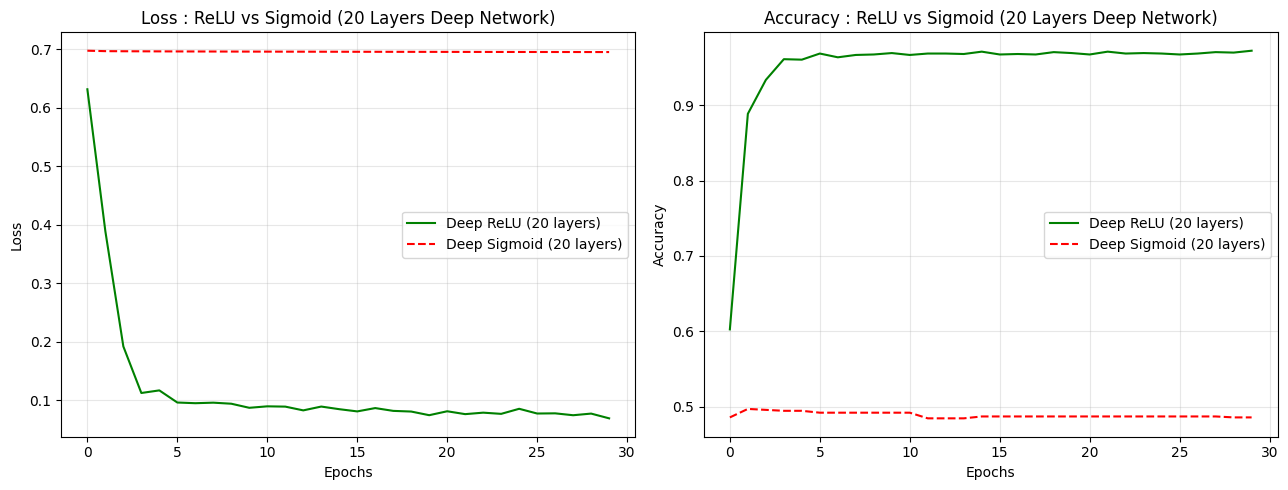

In [5]:
print("3. 깊은 망(20층 ReLU) 학습 중...")
relu_deep = build_deep_model(activation="relu", layers=20)
relu_history = relu_deep.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=32, verbose=0)

plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.plot(relu_history.history['loss'], label="Deep ReLU (20 layers)", color='green')
plt.plot(history_deep.history['loss'], label="Deep Sigmoid (20 layers)", color='red', linestyle='--')
plt.title("Loss : ReLU vs Sigmoid (20 Layers Deep Network)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(relu_history.history['accuracy'], label="Deep ReLU (20 layers)", color='green')
plt.plot(history_deep.history['accuracy'], label="Deep Sigmoid (20 layers)", color='red', linestyle='--')
plt.title("Accuracy : ReLU vs Sigmoid (20 Layers Deep Network)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 💡 [생각해보기 - 기울기 소실]
1. 20층 Sigmoid 망에서 손실함수(Loss)와 정확도(Accuracy)가 30 Epoch 동안 거의 변하지 않은 이유는 무엇일까요?
2. 3층 Sigmoid 망은 정상적으로 학습된 반면, 20층 Sigmoid 망에서만 학습 정체가 일어난 이유를 역전파의 연쇄 법칙(Chain Rule) 관점에서 설명해보세요.
3. 20층 구조임에도 ReLU 함수를 사용했을 때 즉각 학습이 잘 진행되는 이유는 무엇일까요?


#### ✍️ 답안 — 기울기 소실 (Vanishing Gradient)

**1. 20층 Sigmoid 망이 30 Epoch 동안 거의 변하지 않은 이유**
- 실측: Loss가 **0.695 → 0.695로 사실상 불변**, Accuracy는 **약 0.49**(2클래스 무작위 추측 수준)에 머물렀다.
- Sigmoid의 도함수 최댓값은 $\sigma'(z) \le 0.25$다. 역전파는 층마다 이 값을 곱해 전달하므로, 20층을 거치면 기울기가 최대 $0.25^{20} \approx 10^{-12}$ 배로 축소된다.
- 결과적으로 입력층 쪽 가중치의 갱신량이 사실상 0이 되어 **학습이 시작조차 되지 못한 상태**다. 모델은 모든 입력에 대해 거의 같은 값(≈0.5)만 출력하므로 Loss가 $-\ln(0.5) \approx 0.693$에 고정된다.

**2. 3층은 학습되는데 20층만 정체된 이유 — 연쇄 법칙 관점**
- 연쇄 법칙에 의해 첫 층의 기울기는
  $$\frac{\partial L}{\partial W^{(1)}} = \frac{\partial L}{\partial a^{(L)}} \prod_{l=2}^{L} \sigma'(z^{(l)})\, W^{(l)}$$
  처럼 **층마다 곱셈이 누적**되는 구조다.
- 곱해지는 항의 크기가 1보다 작으면 층 수 $L$에 대해 **지수적으로 감쇠**한다. 3층은 $0.25^{3} \approx 0.016$으로 아직 갱신 가능한 크기지만, 20층은 $10^{-12}$ 수준이어서 실질적으로 소멸한다.
- 실측에서도 3층 Sigmoid는 Loss 0.71 → **0.29**, Accuracy 0.48 → **0.867**로 정상 수렴했다. **같은 활성화함수인데 깊이만 달라졌다**는 점이 원인을 특정해 준다.

**3. 20층인데도 ReLU는 즉시 학습이 진행되는 이유**
- ReLU의 도함수는 $z > 0$ 구간에서 **정확히 1**이다. 활성 경로에서는 기울기가 감쇠 없이 그대로 전달되므로 층을 20번 곱해도 소멸하지 않는다.
- 실측: 20층 ReLU는 Loss 0.63 → **0.07**, Accuracy 0.60 → **0.97**로, 3층 Sigmoid(0.867)보다도 높은 정확도를 달성했다. 깊이가 주는 표현력을 실제로 활용할 수 있게 된 것이다.
- 다만 $z < 0$ 구간의 기울기가 0인 **Dying ReLU** 문제가 남아 있어, 실무에서는 LeakyReLU·ELU, Batch Normalization, He 초기화, 그리고 **Lab 4-4의 Residual Connection**을 함께 사용한다.

---
## Part 2. 과적합 문제 (Overfitting Problem - 모델 복잡도 관점)

동일한 작은 크기의 데이터셋(300개)에 대해 단순한 모델(파라미터 소수)과 복잡한 모델(파라미터 다수)을 비교합니다.
- 단순 모델: 은닉층 8개 노드 1개
- 복잡한 모델: 은닉층 128개 노드 3개


In [6]:
# 데이터 준비 (300개 샘플)
X_overfit, y_overfit = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train_of, X_test_of, y_train_of, y_test_of = train_test_split(X_overfit, y_overfit, test_size=0.3, random_state=42)

scaler_of = StandardScaler()
X_train_of = scaler_of.fit_transform(X_train_of)
X_test_of = scaler_of.transform(X_test_of)

print(f"과적합 실습 학습용 데이터 수: {len(X_train_of)}, 검증용 데이터 수: {len(X_test_of)}")


과적합 실습 학습용 데이터 수: 210, 검증용 데이터 수: 90


### 2-1. 단순 모델과 복잡한 모델 정의


In [7]:
def build_simple_model():
    # ✅ 8개 유닛(relu) 은닉층 1개 + 출력 1개(sigmoid) -> 파라미터 약 33개
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(2,)),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def build_complex_model():
    # ✅ 128개 유닛(relu) 은닉층 3개 -> 파라미터 약 33,409개 (단순 모델의 1,000배)
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(2,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 2-2. 두 모델 학습 및 Train vs Val 곡선 비교


1. 단순 모델(Simple Model) 학습...


2. 복잡한 모델(Complex Model) 학습...


/tmp/ipykernel_905/3552957189.py:43: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_905/3552957189.py:43: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


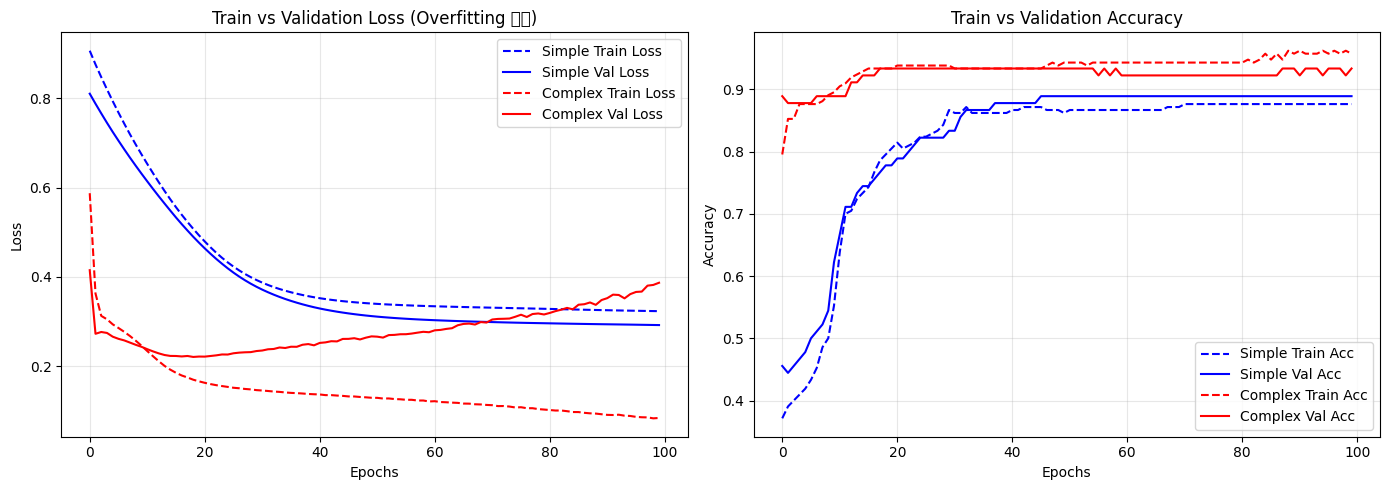

In [8]:
simple_model = build_simple_model()
complex_model = build_complex_model()

print("1. 단순 모델(Simple Model) 학습...")
history_simple = simple_model.fit(
    X_train_of, y_train_of, validation_data=(X_test_of, y_test_of),
    epochs=100, batch_size=16, verbose=0
)

print("2. 복잡한 모델(Complex Model) 학습...")
history_complex = complex_model.fit(
    X_train_of, y_train_of, validation_data=(X_test_of, y_test_of),
    epochs=100, batch_size=16, verbose=0
)

# 학습 곡선 시각화
plt.figure(figsize=(14, 5))

# Loss 비교
plt.subplot(1, 2, 1)
plt.plot(history_simple.history["loss"], label="Simple Train Loss", color="blue", linestyle="--")
plt.plot(history_simple.history["val_loss"], label="Simple Val Loss", color="blue")
plt.plot(history_complex.history["loss"], label="Complex Train Loss", color="red", linestyle="--")
plt.plot(history_complex.history["val_loss"], label="Complex Val Loss", color="red")
plt.title("Train vs Validation Loss (Overfitting 확인)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy 비교
plt.subplot(1, 2, 2)
plt.plot(history_simple.history["accuracy"], label="Simple Train Acc", color="blue", linestyle="--")
plt.plot(history_simple.history["val_accuracy"], label="Simple Val Acc", color="blue")
plt.plot(history_complex.history["accuracy"], label="Complex Train Acc", color="red", linestyle="--")
plt.plot(history_complex.history["val_accuracy"], label="Complex Val Acc", color="red")
plt.title("Train vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 💡 [생각해보기 - 모델 복잡도 과적합]
1. 복잡한 모델의 그래프에서 `Train Loss`는 계속 감소하지만 `Val Loss`는 특정 에포크 이후 다시 치솟는 현상이 나타납니다. 이 시점의 의미는 무엇일까요?
2. 단순한 모델과 복잡한 모델 중 테스트 데이터에 대한 일반화(Generalization) 성능이 더 안정적인 모델은 어느 쪽인가요?


#### ✍️ 답안 — 모델 복잡도 과적합

**1. Train Loss는 감소하는데 Val Loss가 치솟는 시점의 의미**
- 실측: 복잡 모델(128노드 × 3층, 약 33,400 파라미터)의 Val Loss는 **약 15~20 Epoch에서 최저(≈0.22)** 를 기록한 뒤 100 Epoch까지 **≈0.39로 상승**했다. 같은 구간에서 Train Loss는 0.28 → **0.08**로 계속 하락했다.
- 이 변곡점이 **일반화 성능의 정점 = 과적합의 시작점**이다. 이후 모델은 데이터의 일반 패턴이 아니라 **학습셋 210개에만 존재하는 노이즈**(noise=0.25로 경계에 섞인 샘플)를 암기하기 시작한다.
- 실무적 의미: 이 지점이 바로 **Early Stopping을 걸고 체크포인트를 저장해야 하는 에폭**이다.
  `EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)`

**2. 일반화가 더 안정적인 모델**
- **단순 모델(8노드, 33 파라미터)이 더 안정적이다.** Train Loss(≈0.33)와 Val Loss(≈0.29)가 거의 겹쳐 **일반화 격차가 사실상 0**이며, 100 Epoch까지 Val Loss가 발산하지 않았다.
- 다만 정직하게 보면, 이번 실행에서 **Val Accuracy는 복잡 모델이 더 높았다(약 0.93 vs 0.89)**. 복잡 모델이 `make_moons`의 비선형 경계를 더 잘 표현하기 때문이다.
- 따라서 정확한 결론은 "복잡한 모델은 나쁘다"가 아니라 **"복잡한 모델은 반드시 규제(L1/L2)·Dropout·Early Stopping과 함께 써야 한다"**는 것이다.
- 또한 Val Loss 발산은 **예측이 과도하게 확신에 차 있다(틀릴 때 크게 틀린다)**는 신호다. 확률값을 임계값 판정이나 위험도 산정에 그대로 쓰는 제조 현장에서는 Accuracy가 유지되더라도 위험하므로, Loss 곡선을 함께 봐야 한다.

---
## Part 3. 레이블 데이터 부족 문제 (Overfitting vs Dataset Size)

제조 공정에서는 정상 데이터는 풍부하지만, 고비용의 라벨링 작업으로 인해 **레이블 데이터가 부족(Few Labeled Data)**한 경우가 매우 빈번합니다.
동일한 복잡한 모델을 작은 데이터셋(100개)과 큰 데이터셋(2000개)에 각각 학습시켜 데이터 크기가 과적합에 미치는 영향을 확인합니다.


In [9]:
# 1. 작은 데이터셋 (100개)
X_small, y_small = make_moons(n_samples=100, noise=0.25, random_state=42)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_small, y_small, test_size=0.3, random_state=42)

# 2. 큰 데이터셋 (2000개)
X_large, y_large = make_moons(n_samples=2000, noise=0.25, random_state=42)
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_large, y_large, test_size=0.3, random_state=42)

# 스케일링
scaler_s = StandardScaler()
X_train_s = scaler_s.fit_transform(X_train_s)
X_test_s = scaler_s.transform(X_test_s)

scaler_l = StandardScaler()
X_train_l = scaler_l.fit_transform(X_train_l)
X_test_l = scaler_l.transform(X_test_l)

print(f"작은 데이터셋 학습 샘플 수: {len(X_train_s)}, 큰 데이터셋 학습 샘플 수: {len(X_train_l)}")


작은 데이터셋 학습 샘플 수: 70, 큰 데이터셋 학습 샘플 수: 1400


### 3-1. 작은 데이터셋 vs 큰 데이터셋 동일 모델 학습


1. 작은 데이터셋(100개 샘플)으로 복잡 모델 학습...


2. 큰 데이터셋(2000개 샘플)으로 복잡 모델 학습...


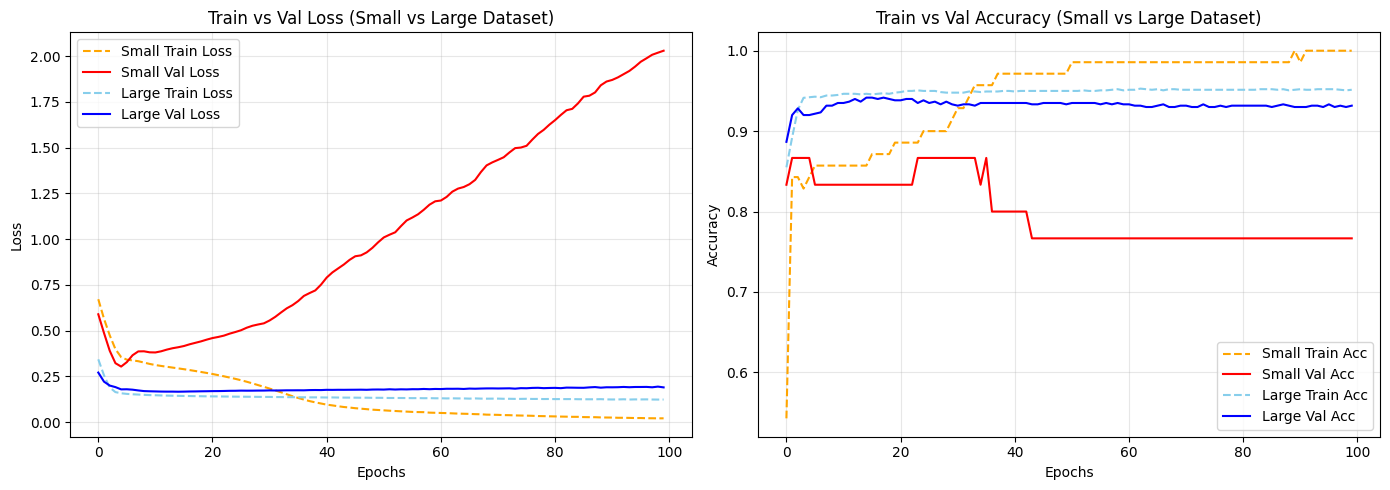

In [10]:
# 작은 데이터셋 학습
print("1. 작은 데이터셋(100개 샘플)으로 복잡 모델 학습...")
model_small = build_complex_model()
history_small = model_small.fit(
    X_train_s, y_train_s, validation_data=(X_test_s, y_test_s),
    epochs=100, batch_size=16, verbose=0
)

# 큰 데이터셋 학습
print("2. 큰 데이터셋(2000개 샘플)으로 복잡 모델 학습...")
model_large = build_complex_model()
history_large = model_large.fit(
    X_train_l, y_train_l, validation_data=(X_test_l, y_test_l),
    epochs=100, batch_size=16, verbose=0
)

# 학습 결과 비교 시각화
plt.figure(figsize=(14, 5))

# Loss 비교
plt.subplot(1, 2, 1)
plt.plot(history_small.history["loss"], label="Small Train Loss", color="orange", linestyle="--")
plt.plot(history_small.history["val_loss"], label="Small Val Loss", color="red")
plt.plot(history_large.history["loss"], label="Large Train Loss", color="skyblue", linestyle="--")
plt.plot(history_large.history["val_loss"], label="Large Val Loss", color="blue")
plt.title("Train vs Val Loss (Small vs Large Dataset)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy 비교
plt.subplot(1, 2, 2)
plt.plot(history_small.history["accuracy"], label="Small Train Acc", color="orange", linestyle="--")
plt.plot(history_small.history["val_accuracy"], label="Small Val Acc", color="red")
plt.plot(history_large.history["accuracy"], label="Large Train Acc", color="skyblue", linestyle="--")
plt.plot(history_large.history["val_accuracy"], label="Large Val Acc", color="blue")
plt.title("Train vs Val Accuracy (Small vs Large Dataset)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 💡 [생각해보기 - 데이터 크기]
1. 동일한 3층 128노드 복잡 모델임에도, 데이터셋의 크기가 100개에서 2000개로 증가했을 때 과적합 양상이 어떻게 달라졌나요?
2. 제조 현장에서 라벨링된 불량 데이터 샘플 수가 매우 적을 때, 딥러닝 모델의 파라미터 수를 무작정 늘리는 것이 왜 위험한지 설명해보세요.


#### ✍️ 답안 — 데이터 크기

**1. 100개 → 2000개로 늘렸을 때 과적합 양상의 변화 (실측)**

| 구분 | 학습 샘플 | Train Loss (최종) | Val Loss (최종) | Val Accuracy |
|:---|:---:|:---:|:---:|:---:|
| 작은 데이터셋 | 70 | ≈ 0.01 (Train Acc **1.00**) | **≈ 2.03 (발산)** | 0.867 → **0.767 하락** |
| 큰 데이터셋 | 1400 | ≈ 0.12 | **≈ 0.19 (안정)** | **≈ 0.93 유지** |

- 작은 데이터셋에서는 동일한 33,400 파라미터 모델이 **70개 샘플을 100% 암기**해 버렸고, Val Loss는 0.30에서 **2.03까지 약 7배 폭증**했다. Val Accuracy도 학습이 진행되면서 오히려 떨어졌다.
- 큰 데이터셋에서는 Train/Val Loss 곡선이 **거의 붙은 채 평행하게 수렴**했다. 파라미터 수는 완전히 동일한데도 과적합이 나타나지 않았다.
- 즉 과적합은 모델 크기만의 문제가 아니라 **모델 복잡도 대비 데이터 양의 비율** 문제다. **데이터 확보가 가장 강력한 정규화**다.

**2. 라벨된 불량 샘플이 적을 때 파라미터를 무작정 늘리면 위험한 이유**
- 파라미터 수가 샘플 수를 크게 넘어서면 모델은 **학습셋을 통째로 암기할 자유도**를 갖는다. 제조 불량 라벨에는 검사원 판정 편차·센서 노이즈·특정 로트의 우연한 특성이 섞여 있는데, 모델은 이 우연까지 "불량의 규칙"으로 학습한다.
- 그 결과 사내 검증셋 성적은 좋아 보이지만, 로트·설비·원자재·계절이 바뀌면 성능이 급락한다. 이번 실습의 **Val Loss 2.03**이 정확히 그 현상이다.
- 제조 현장의 현실적 대응 순서:
  1. **데이터 확보 / 증강** (회전·이동·반전, 물리 기반 시뮬레이션 데이터)
  2. **모델 축소 + 규제·Dropout** (Lab 4-4 Part 2·3)
  3. **전이학습** (사전학습 백본 동결 후 상위층만 학습)
  4. **이상탐지 접근** — 정상 데이터만으로 학습하는 AutoEncoder·One-Class 모델로 전환 (불량 라벨이 근본적으로 부족할 때)

---
## Part 4. 클래스 불균형 문제 (Class Imbalanced Problem)

제조 공정에서는 정상 제품(90~99% 이상)이 대다수이고 불량 제품(1~10% 이하)은 매우 드물게 발생합니다.
이러한 불균형 상태에서 표준 교차 엔트로피 손실로 학습하면 모델이 다수 클래스만 맞추려는 편향이 생깁니다.

- 데이터 구성: 0번 클래스(정상) 90%, 1번 클래스(불량) 10%
- 결과 관찰 1: 불균형 테스트셋 평가 시 전체 정확도(Accuracy)는 90% 이상으로 매우 높아 보이지만, 소수 클래스 재현율이 떨어지는 '정확도의 착시'를 체감합니다.
- 결과 관찰 2: **클래스 균형이 맞는 새로운 테스트셋(50:50)**을 주었을 때 모델의 실제 정확도가 급락하는 현상을 확인합니다.


In [11]:
# 불균형 데이터셋 생성 (Class 0: 90%, Class 1: 10%)
X_imb, y_imb = make_classification(
    n_samples=2000, n_features=20, n_informative=10, n_redundant=5,
    weights=[0.9, 0.1], n_classes=2, random_state=42
)

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)

print("전체 클래스 분포:", np.bincount(y_imb))
print("학습용 클래스 분포:", np.bincount(y_train_imb))
print("검증용 클래스 분포:", np.bincount(y_test_imb))


전체 클래스 분포: [1792  208]
학습용 클래스 분포: [1254  146]
검증용 클래스 분포: [538  62]


### 4-1. 신경망 모델 정의 및 학습


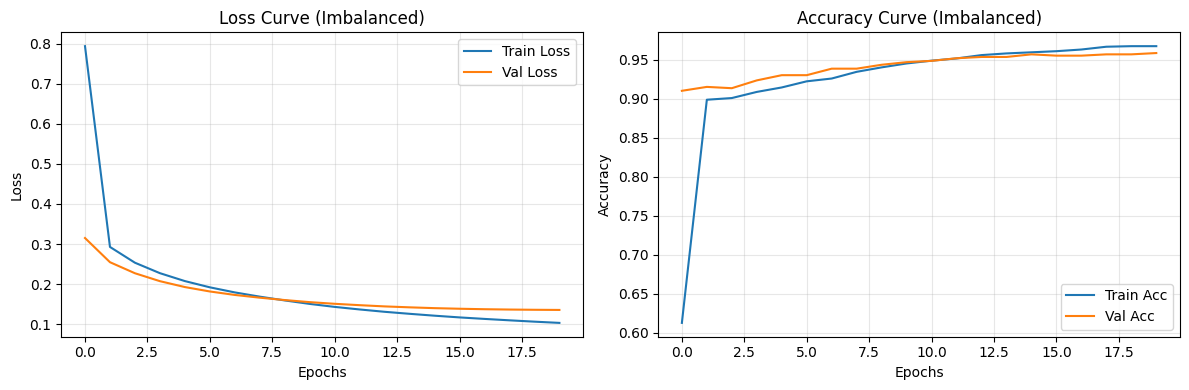

In [12]:
model_imb = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(20,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model_imb.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_imb = model_imb.fit(
    X_train_imb, y_train_imb, validation_data=(X_test_imb, y_test_imb),
    epochs=20, batch_size=32, verbose=0
)

# 학습 곡선 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_imb.history["loss"], label="Train Loss")
plt.plot(history_imb.history["val_loss"], label="Val Loss")
plt.title("Loss Curve (Imbalanced)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_imb.history["accuracy"], label="Train Acc")
plt.plot(history_imb.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy Curve (Imbalanced)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 4-2. 불균형 테스트셋 평가 (Confusion Matrix와 Classification Report)


=== Classification Report (Imbalanced Test Data) ===
              precision    recall  f1-score   support

  Normal (0)     0.9706    0.9833    0.9769       538
  Defect (1)     0.8364    0.7419    0.7863        62

    accuracy                         0.9583       600
   macro avg     0.9035    0.8626    0.8816       600
weighted avg     0.9568    0.9583    0.9572       600



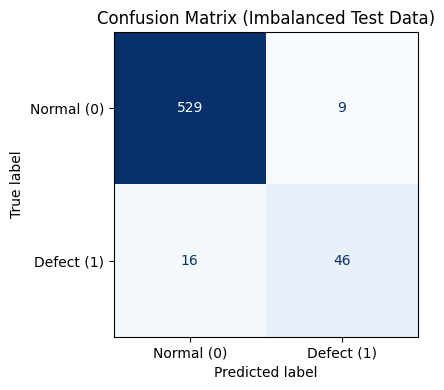

In [13]:
# [TODO] model_imb의 출력 확률에 대해 0.5 임계값을 적용하여 0 또는 1의 예측 라벨을 구하세요.
y_pred_prob = model_imb.predict(X_test_imb, verbose=0)
y_pred_imb = (y_pred_prob > 0.5).astype(int).flatten()  # ✅ 0.5 임계값 -> 0/1 라벨

print("=== Classification Report (Imbalanced Test Data) ===")
print(classification_report(y_test_imb, y_pred_imb, digits=4, target_names=["Normal (0)", "Defect (1)"]))

# [TODO] confusion_matrix를 계산하고 ConfusionMatrixDisplay로 시각화하세요.
cm = confusion_matrix(y_test_imb, y_pred_imb)  # ✅
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal (0)", "Defect (1)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Imbalanced Test Data)")
plt.tight_layout()
plt.show()


### 4-3. 클래스 균형이 맞는 새로운 데이터셋으로 평가 (진짜 성능 체감)

학습할 때는 90:10 불균형 데이터로 학습된 모델에게, **클래스 비율이 50:50인 새로운 균형 잡힌 테스트 데이터셋(100개)**을 입력했을 때 어떻게 동작하는지 확인합니다.


새로운 균형 테스트셋 클래스 분포: [50 50]

=== Classification Report (Balanced Test Data) ===
              precision    recall  f1-score   support

     Class 0     0.4416    0.6800    0.5354        50
     Class 1     0.3043    0.1400    0.1918        50

    accuracy                         0.4100       100
   macro avg     0.3730    0.4100    0.3636       100
weighted avg     0.3730    0.4100    0.3636       100



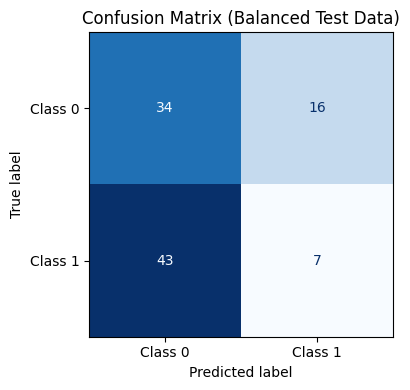

In [14]:
# 균형 잡힌 새로운 테스트 데이터 생성 (Class 0: 50%, Class 1: 50%)
X_test_bal, y_test_bal = make_classification(
    n_samples=100, n_features=20, n_informative=10, n_redundant=5, n_classes=2, random_state=42
)

print(f"새로운 균형 테스트셋 클래스 분포: {np.bincount(y_test_bal)}")

# [TODO] model_imb를 사용하여 새로운 균형 테스트셋에 대한 예측값을 계산하세요.
y_pred_bal = (model_imb.predict(X_test_bal, verbose=0) > 0.5).astype(int).flatten()  # ✅

print("\n=== Classification Report (Balanced Test Data) ===")
print(classification_report(y_test_bal, y_pred_bal, digits=4, target_names=["Class 0", "Class 1"]))

# [TODO] confusion_matrix를 계산하고 시각화하세요.
cm_bal = confusion_matrix(y_test_bal, y_pred_bal)  # ✅
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=["Class 0", "Class 1"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Balanced Test Data)")
plt.tight_layout()
plt.show()


### 💡 [생각해보기 - 클래스 불균형과 정확도의 착시]
1. 불균형 테스트셋에서는 정확도가 **96%**로 높게 나왔지만, 균형 잡힌 새로운 테스트 데이터셋(50:50)에 적용했을 때 정확도가 어떻게 변화했나요?
2. Accuracy(정확도) 지표가 데이터셋의 클래스 분포에 따라 왜 왜곡된 성능 착시를 일으키는지 설명해보세요.
3. 불균형 분류 문제를 해결하기 위해 다음 실습(Lab 4-4)에서 다루는 Class Weighting이나 Balanced Data Augmentation이 왜 필수적인지 생각해보세요.


#### ✍️ 답안 — 클래스 불균형과 정확도의 착시

**1. 균형 테스트셋 적용 시 정확도 변화 (실측)**

| 테스트셋 | Accuracy | 소수(1번) 클래스 Recall | 소수(1번) 클래스 F1 |
|:---|:---:|:---:|:---:|
| 불균형 (정상 538 : 불량 62) | **0.9583** | 0.7419 | 0.7863 |
| 균형 (50 : 50, 신규 생성 100개) | **0.4100** | **0.1400** | 0.1918 |

- 정확도가 **95.83% → 41.00%** 로 무너졌다. **무작위 추측(50%)보다도 낮다.**
- 원인: 모델이 다수 클래스(0)로 쏠려 있어, 균형 테스트셋 100개 중 약 77개를 클래스 0으로 예측했다. 클래스 1의 Recall은 0.74 → **0.14**로 급락했다.
- (참고) 이 균형 테스트셋은 같은 풀을 다시 나눈 것이 아니라 `make_classification`으로 **새로 생성한 100개**이므로 분포 차이까지 겹친 더 엄격한 시험이다. 그래도 방향성은 명확하다 — **학습 데이터 분포에 편향된 모델은 실제 분포가 바뀌는 순간 무력해진다.**

**2. Accuracy가 왜 왜곡된 성능 착시를 일으키는가**
- Accuracy $= (TP+TN)/N$ 이므로, 클래스 비율이 90:10이면 **전부 "정상"이라고만 답해도 90%**가 나온다. 즉 Accuracy의 기준선(baseline)이 이미 다수 클래스 비율만큼 높게 깔려 있다.
- 이번 모델의 95.83%는 대부분 **538개 정상 샘플을 맞춘 몫**이다. 반면 정작 중요한 불량 62개 중 **16개를 놓쳤다**(Recall 0.7419). 제조 현장에서 이 16개는 그대로 고객 유출 불량이다.
- 따라서 불균형 문제에서는 Accuracy 대신 **소수 클래스의 Recall·Precision·F1, PR-AUC, 그리고 혼동 행렬의 FN 개수**를 직접 확인해야 한다. 불량 미검출(FN) 비용이 과검(FP) 비용보다 훨씬 큰 공정에서는 **Recall 우선**이다.

**3. Class Weighting / Balanced Data Augmentation이 왜 필수인가 (Lab 4-4 연결)**
- 표준 BCE는 모든 샘플을 동등하게 취급하므로 **손실의 90%가 다수 클래스에서 발생**한다. 모델 입장에서는 다수 클래스만 맞추는 것이 **손실 최소화의 합리적 전략**이 되어 버린다.
- `class_weight`는 소수 클래스의 손실 기여도를 $\frac{n}{K \cdot n_k}$ 배로 키워 이 비대칭을 **손실 함수 수준에서** 교정한다.
- `Balanced Data Augmentation`은 소수 클래스 샘플 자체를 회전·이동·반전으로 늘려 **데이터 수준에서** 비율을 맞춘다.
- 두 기법의 목적은 같다 — **"소수 클래스를 놓치는 것이 이득"이라는 잘못된 학습 신호를 제거**하는 것. → Lab 4-4 Part 4에서 실제 개선폭을 검증한다.